### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.0.0-beta1'

In [3]:
tf.random.set_seed(42)

### Collect Data

In [4]:
import keras

Using TensorFlow backend.


In [5]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [6]:
np.unique(trainY)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [7]:
num_classes = 10 # No. of unique fashion product
# Convert class vectors to binary class matrices
trainY = keras.utils.to_categorical(trainY, num_classes)
testY = keras.utils.to_categorical(testY, num_classes)

In [8]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

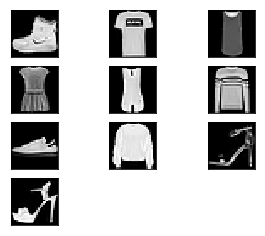

label for each of the above image:
 [9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


In [9]:


labels = []

plt.figure(figsize=(5,5))
for i in range(10):
    plt.subplot(5,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))
    np.where(trainY[i] == 1)[0][0]
    lbl=np.where(trainY[i] == 1)[0][0]
    labels.append(lbl)
plt.show()
print("label for each of the above image:\n", labels)

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [10]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Comile the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

### Execute the model using model.fit()

In [11]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=10,
          batch_size=32)

W0801 08:01:01.182244  4596 deprecation.py:323] From C:\ProgramData\Anaconda3\lib\site-packages\tensorflow\python\ops\math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 13s 209us/sample - loss: 14.5069 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 2/10
60000/60000 [==============================] - 11s 175us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 3/10
60000/60000 [==============================] - 11s 185us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 4/10
60000/60000 [==============================] - 11s 185us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 5/10
60000/60000 [==============================] - 10s 165us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 6/10
60000/60000 [==============================] - 9s 157us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 7/10
60000/60000 [=========

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [12]:
#Initialize Sequential model
model = tf.keras.models.Sequential()
#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))
#Batch normalization of the data 
model.add(tf.keras.layers.BatchNormalization())
#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#Comile the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

### Execute the model

In [13]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=10,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 14s 230us/sample - loss: 0.5944 - accuracy: 0.7955 - val_loss: 0.5104 - val_accuracy: 0.8282
Epoch 2/10
60000/60000 [==============================] - 12s 201us/sample - loss: 0.4883 - accuracy: 0.8321 - val_loss: 0.4939 - val_accuracy: 0.8312
Epoch 3/10
60000/60000 [==============================] - 10s 173us/sample - loss: 0.4697 - accuracy: 0.8381 - val_loss: 0.4736 - val_accuracy: 0.8327
Epoch 4/10
60000/60000 [==============================] - 9s 154us/sample - loss: 0.4545 - accuracy: 0.8433 - val_loss: 0.4763 - val_accuracy: 0.8392
Epoch 5/10
60000/60000 [==============================] - 12s 199us/sample - loss: 0.4491 - accuracy: 0.8453 - val_loss: 0.4686 - val_accuracy: 0.8379
Epoch 6/10
60000/60000 [==============================] - 10s 172us/sample - loss: 0.4430 - accuracy: 0.8460 - val_loss: 0.4692 - val_accuracy: 0.8394
Epoch 7/10
60000/60000 [=====================

### Observation :
     1. Model with Batch Normalization the Accuracy rate is 85%  with 10 epochs.

In [14]:
#Initialize Sequential model
model = tf.keras.models.Sequential()
#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))
#Normalize the data 
model.add(tf.keras.layers.BatchNormalization())
#Add Dense Layer to create a hidden layer of 128 neurons with Relu activation
model.add(tf.keras.layers.Dense(128, activation='relu'))
#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#Comile the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=5,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 13s 215us/sample - loss: 0.5539 - accuracy: 0.8079 - val_loss: 0.4517 - val_accuracy: 0.8411
Epoch 2/5
60000/60000 [==============================] - 7s 123us/sample - loss: 0.4159 - accuracy: 0.8507 - val_loss: 0.4138 - val_accuracy: 0.8532
Epoch 3/5
60000/60000 [==============================] - 15s 256us/sample - loss: 0.3793 - accuracy: 0.8637 - val_loss: 0.3979 - val_accuracy: 0.8594
Epoch 4/5
60000/60000 [==============================] - 15s 249us/sample - loss: 0.3606 - accuracy: 0.8702 - val_loss: 0.3816 - val_accuracy: 0.8613
Epoch 5/5
60000/60000 [==============================] - 13s 220us/sample - loss: 0.3422 - accuracy: 0.8766 - val_loss: 0.3750 - val_accuracy: 0.8653


### Observation :
   1. When we repeat the Model with Batch Normalization plus on more hidden layer of 128 neurons with Relu activation the Accuracy rate is 87%  with 10 epochs

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [16]:
## Change the learning rate to 0.001 in sgd optimizer
sgd_optimizer = tf.keras.optimizers.SGD(lr=0.001)
model.compile(optimizer=sgd_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=10,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 11s 185us/sample - loss: 0.3216 - accuracy: 0.8831 - val_loss: 0.3695 - val_accuracy: 0.8682
Epoch 2/10
60000/60000 [==============================] - 6s 100us/sample - loss: 0.3190 - accuracy: 0.8842 - val_loss: 0.3657 - val_accuracy: 0.8682
Epoch 3/10
60000/60000 [==============================] - 6s 97us/sample - loss: 0.3170 - accuracy: 0.8862 - val_loss: 0.3655 - val_accuracy: 0.8680
Epoch 4/10
60000/60000 [==============================] - 6s 100us/sample - loss: 0.3157 - accuracy: 0.8868 - val_loss: 0.3658 - val_accuracy: 0.8700
Epoch 5/10
60000/60000 [==============================] - 6s 106us/sample - loss: 0.3160 - accuracy: 0.8871 - val_loss: 0.3635 - val_accuracy: 0.8712
Epoch 6/10
60000/60000 [==============================] - 10s 160us/sample - loss: 0.3133 - accuracy: 0.8874 - val_loss: 0.3667 - val_accuracy: 0.8691
Epoch 7/10
60000/60000 [=========================

### Observation :
    1. Model Accuracy is 88% when SGD learning rate set to 0.01 with 10 epochs

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [22]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Normalize the data 
model.add(tf.keras.layers.BatchNormalization())

#Add Dense Layer to create a hidden layer of 100 neurons with sigmoid activation
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))

#Add Dense Layer to create a hidden layer of 100 neurons with sigmoid activation
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))

#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Comile the model with SGD optimizer learning rate 0.03
sgd_optimizer = tf.keras.optimizers.SGD(lr=0.03)
model.compile(optimizer=sgd_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

## Review model

In [19]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_3 (Reshape)          (None, 784)               0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 784)               3136      
_________________________________________________________________
dense_4 (Dense)              (None, 100)               78500     
_________________________________________________________________
dense_5 (Dense)              (None, 100)               10100     
_________________________________________________________________
dense_6 (Dense)              (None, 10)                1010      
Total params: 92,746
Trainable params: 91,178
Non-trainable params: 1,568
_________________________________________________________________


### Run the model

In [23]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=10,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 10s 168us/sample - loss: 1.0272 - accuracy: 0.6955 - val_loss: 0.6353 - val_accuracy: 0.7757
Epoch 2/10
60000/60000 [==============================] - 6s 105us/sample - loss: 0.5738 - accuracy: 0.7980 - val_loss: 0.5144 - val_accuracy: 0.8149
Epoch 3/10
60000/60000 [==============================] - 6s 107us/sample - loss: 0.4949 - accuracy: 0.8241 - val_loss: 0.4673 - val_accuracy: 0.8317
Epoch 4/10
60000/60000 [==============================] - 6s 107us/sample - loss: 0.4542 - accuracy: 0.8382 - val_loss: 0.4449 - val_accuracy: 0.8385
Epoch 5/10
60000/60000 [==============================] - 7s 109us/sample - loss: 0.4319 - accuracy: 0.8453 - val_loss: 0.4368 - val_accuracy: 0.8426
Epoch 6/10
60000/60000 [==============================] - 7s 115us/sample - loss: 0.4137 - accuracy: 0.8511 - val_loss: 0.4189 - val_accuracy: 0.8475
Epoch 7/10
60000/60000 [=========================

### Observation :
    1. Model Accuracy is 86% for 3 Dense layers with 100,100,10 neurons respectively in each layer plus sgd optimizer with learning rate 0.03